# UpSet Plot

[UpSet plots](https://caleydo.org/tools/upset/) provide an efficient way to visualize intersections of multiple sets compared to traditional Venn diagrams. In **complexheatmap**, UpSet plots are implemented as specialized heatmaps, combining a binary combination matrix with barplot annotations.

This tutorial covers: creating combination matrices with `make_comb_mat`, querying sizes with `comb_size` and `set_size`, making UpSet plots, annotations, and the three modes (distinct, intersect, union).

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import (
    make_comb_mat, CombMat,
    comb_degree, comb_name, comb_size,
    set_name, set_size, extract_comb,
    normalize_comb_mat,
    UpSet, upset_top_annotation, upset_right_annotation,
    list_to_matrix
)
import grid_py as gp

## Input Data

Multiple sets can be represented as:

1. **A dict of sets** (list of elements per set)
2. **A binary matrix** where rows are elements and columns are sets

Use `list_to_matrix()` to convert from a dict to a binary matrix.

In [2]:
lt = {
    "a": set(range(1, 11)),   # {1, 2, ..., 10}
    "b": set(range(5, 16)),   # {5, 6, ..., 15}
    "c": set(range(8, 21)),   # {8, 9, ..., 20}
}
print(f"Set a: {len(lt['a'])} elements")
print(f"Set b: {len(lt['b'])} elements")
print(f"Set c: {len(lt['c'])} elements")

Set a: 10 elements
Set b: 11 elements
Set c: 13 elements


In [3]:
# Convert to binary matrix
bin_mat, row_names, col_names = list_to_matrix(lt)
print(f"Binary matrix shape: {bin_mat.shape}")
import pandas as pd
print(pd.DataFrame(bin_mat[:10], index=row_names[:10], columns=col_names))


Binary matrix shape: (20, 3)
    a  b  c
1   1  0  0
2   1  0  0
3   1  0  0
4   1  0  0
5   1  1  0
6   1  1  0
7   1  1  0
8   1  1  1
9   1  1  1
10  1  1  1


## Making the Combination Matrix

`make_comb_mat()` generates the combination matrix and calculates sizes. The default mode is `"distinct"`.

In [4]:
m = make_comb_mat(lt)
print(f"Type: {type(m).__name__}")
print(f"Is CombMat: {isinstance(m, CombMat)}")

Type: CombMat
Is CombMat: True


## Utility Functions

Several functions extract information from the combination matrix:

- `set_name(m)`: names of the sets
- `comb_name(m)`: binary-encoded combination set names (e.g., "101" means sets a and c)
- `set_size(m)`: size of each set
- `comb_size(m)`: size of each combination set
- `comb_degree(m)`: number of sets selected in each combination
- `extract_comb(m, name)`: elements in a specific combination set

In [5]:
print("Set names:", list(set_name(m)))
print("Comb names:", list(comb_name(m)))
print("Set sizes:", list(set_size(m)))
print("Comb sizes:", list(comb_size(m)))
print("Comb degrees:", list(comb_degree(m)))

Set names: ['a', 'b', 'c']
Comb names: ['100', '001', '110', '011', '111']
Set sizes: [np.int64(10), np.int64(11), np.int64(13)]
Comb sizes: [np.int64(4), np.int64(5), np.int64(3), np.int64(5), np.int64(3)]
Comb degrees: [np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(3)]


### Verifying set sizes

The set sizes should match the input.

In [6]:
py_set_sizes = set_size(m)
print(f"Set sizes: {list(py_set_sizes)}")
print(f"Expected: a=10, b=11, c=13")

Set sizes: [np.int64(10), np.int64(11), np.int64(13)]
Expected: a=10, b=11, c=13


### Comb degree matches the name

The degree of a combination set equals the number of 1s in its binary name.

In [7]:
names = list(comb_name(m))
degrees = list(comb_degree(m))
expected_degrees = [name.count("1") for name in names]

print(f"Names:    {names}")
print(f"Degrees:  {degrees}")
print(f"Expected: {expected_degrees}")
print(f"Match: {degrees == expected_degrees}")

Names:    ['100', '001', '110', '011', '111']
Degrees:  [np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(3)]
Expected: [1, 1, 2, 2, 3]
Match: True


### `extract_comb`: Get elements in a combination

Use `extract_comb` to retrieve the actual elements belonging to a specific combination set.

In [8]:
# Elements in all three sets (a AND b AND c)
members_111 = extract_comb(m, "111")
print(f"Elements in a AND b AND c: {members_111}")

# Elements only in set a (not b, not c)
members_100 = extract_comb(m, "100")
print(f"Elements only in a: {members_100}")

Elements in a AND b AND c: {8, 9, 10}
Elements only in a: {1, 2, 3, 4}


## Making the UpSet Plot

Simply pass the combination matrix to `UpSet()`. By default, sets are ordered by size and combination sets by degree.

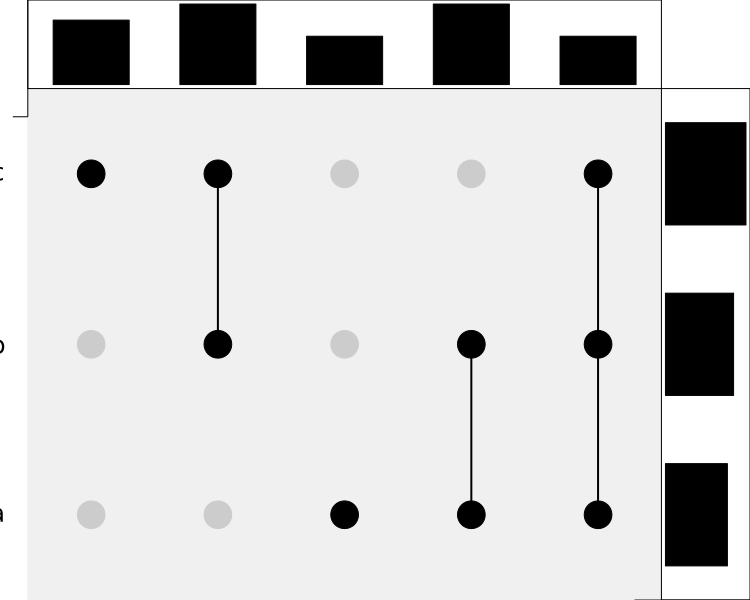

In [9]:
us = UpSet(m)
us.draw()

### Custom ordering

Use `set_order` and `comb_order` to control the display order.

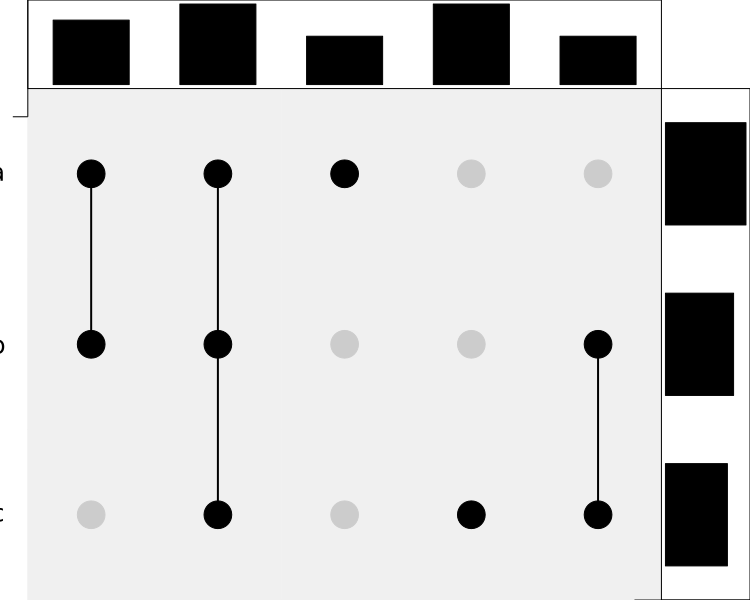

In [10]:
us = UpSet(m,
           set_order=["a", "b", "c"],
           comb_order=np.argsort(comb_size(m)).tolist())
us.draw()

### Colors and styling

Customize dot size, line width, and colors. `comb_col` can use `comb_degree` as an index.

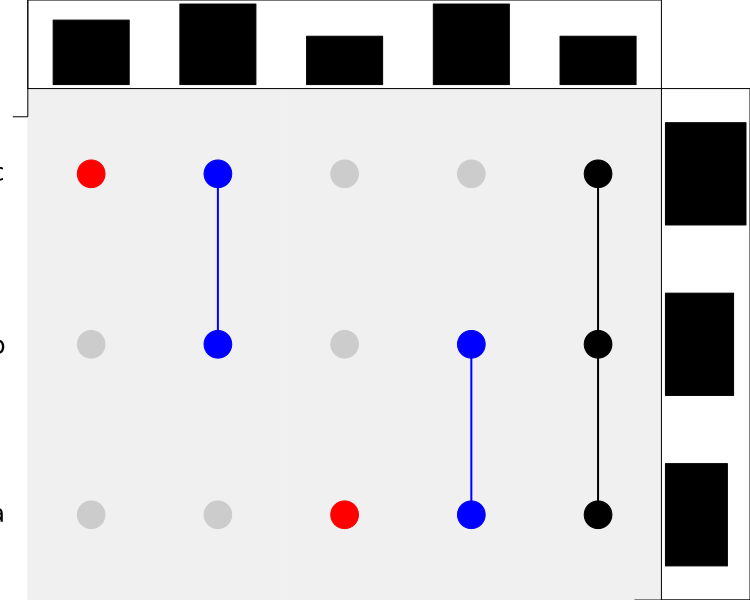

In [11]:
degree_colors = ["red", "blue", "black"]
comb_colors = [degree_colors[d - 1] for d in comb_degree(m)]

us = UpSet(m, comb_col=comb_colors)
us.draw()

## Three Modes

The `mode` argument in `make_comb_mat` controls how combination sizes are calculated:

- **distinct** (default): 1 means in the set, 0 means NOT in the set. Partitions are mutually exclusive (like Venn diagram regions).
- **intersect**: 1 means in the set, 0 is ignored. `"110"` means elements in both A and B (may or may not be in C).
- **union**: 1 means in the set, with OR relationship. `"110"` means elements in A OR B.

In [12]:
m_distinct = make_comb_mat(lt, mode="distinct")
m_intersect = make_comb_mat(lt, mode="intersect")
m_union = make_comb_mat(lt, mode="union")

print("Distinct comb sizes: ", list(comb_size(m_distinct)))
print("Intersect comb sizes:", list(comb_size(m_intersect)))
print("Union comb sizes:    ", list(comb_size(m_union)))

Distinct comb sizes:  [np.int64(4), np.int64(5), np.int64(3), np.int64(5), np.int64(3)]
Intersect comb sizes: [np.int64(10), np.int64(11), np.int64(13), np.int64(6), np.int64(3), np.int64(8), np.int64(3)]
Union comb sizes:     [np.int64(10), np.int64(11), np.int64(13), np.int64(15), np.int64(20), np.int64(16), np.int64(20)]


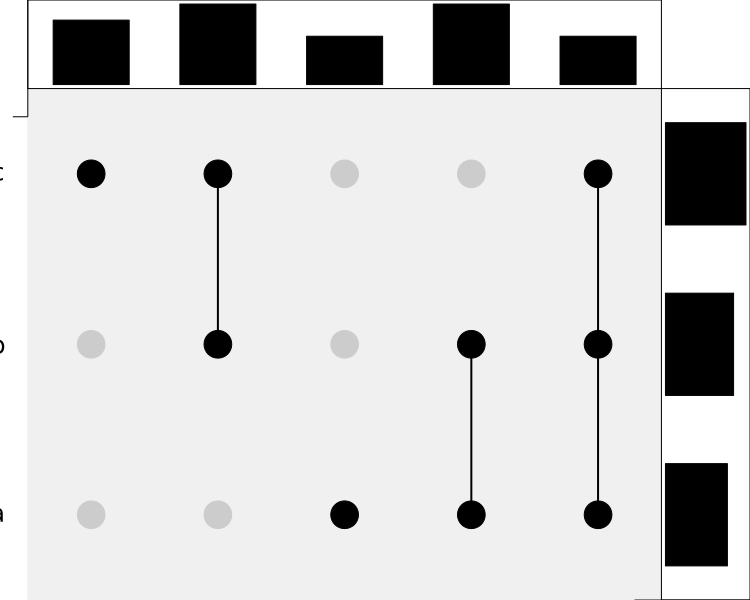

In [13]:
# UpSet plots for each mode
us1 = UpSet(m_distinct)
us1.draw()

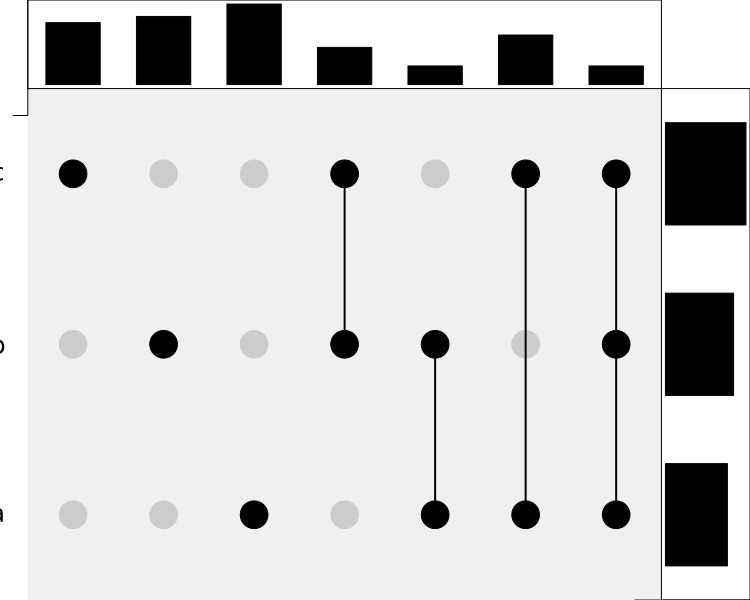

In [14]:
us2 = UpSet(m_intersect)
us2.draw()

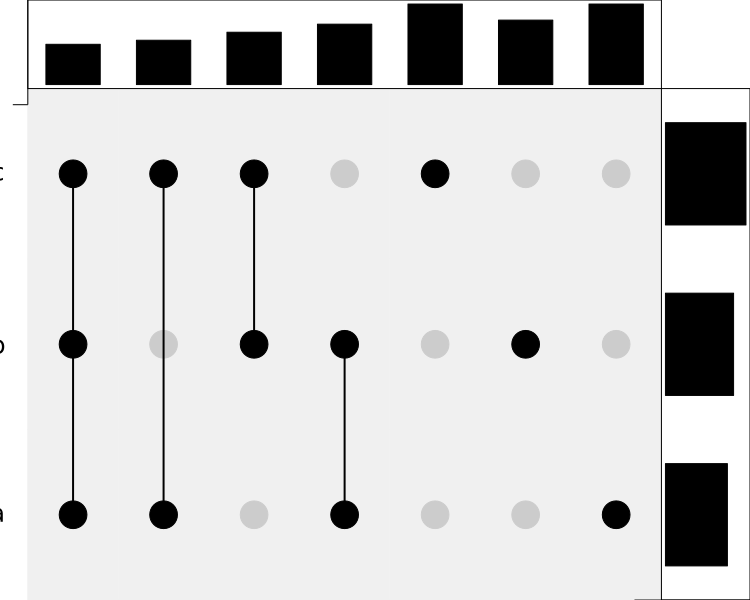

In [15]:
us3 = UpSet(m_union)
us3.draw()

## Filtering Combinations

You can filter the combination matrix by size or degree using indexing.

In [16]:
m = make_comb_mat(lt)

# Keep only combinations with size >= 4
mask_size = np.array(comb_size(m)) >= 4
m_large = m[mask_size]
print(f"Large comb sizes: {list(comb_size(m_large))}")

# Keep only degree-2 combinations
mask_deg = np.array(comb_degree(m)) == 2
m_deg2 = m[mask_deg]
print(f"Degree-2 comb sizes: {list(comb_size(m_deg2))}")

Large comb sizes: [np.int64(4), np.int64(5), np.int64(5)]
Degree-2 comb sizes: [np.int64(3), np.int64(5)]


## UpSet Annotations

The default UpSet plot includes a top barplot annotation for combination sizes and a right barplot annotation for set sizes. These are wrapped in `upset_top_annotation()` and `upset_right_annotation()`.

You can customize these annotations or add your own.

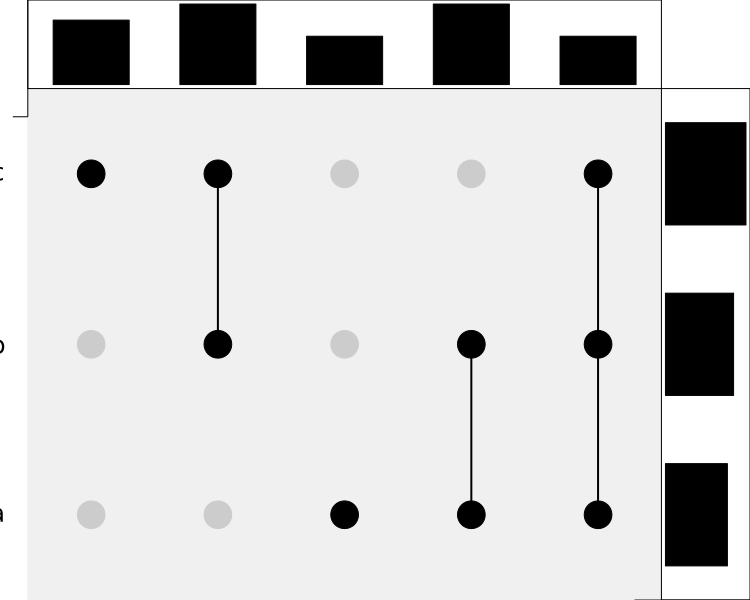

In [17]:
m = make_comb_mat(lt)

# Custom top annotation with colored bars by degree
us = UpSet(m,
    top_annotation=upset_top_annotation(m,
        gp={"col": ["red", "blue", "black"][d - 1] for d in comb_degree(m)}
    )
)
us.draw()

## Universal Set and Complement

You can specify a universal set so that the complement (elements not in any set) is also shown.

In [18]:
np.random.seed(123)
lt_letters = {
    "a": set(np.random.choice(list("abcdefghijklmnopqrstuvwxyz"), 5, replace=False)),
    "b": set(np.random.choice(list("abcdefghijklmnopqrstuvwxyz"), 10, replace=False)),
    "c": set(np.random.choice(list("abcdefghijklmnopqrstuvwxyz"), 15, replace=False)),
}

m_univ = make_comb_mat(lt_letters, universal_set=set("abcdefghijklmnopqrstuvwxyz"))
print(f"Comb names: {list(comb_name(m_univ))}")
print(f"Comb sizes: {list(comb_size(m_univ))}")
print(f"Comb degrees: {list(comb_degree(m_univ))}")

Comb names: ['100', '010', '001', '101', '011', '111']
Comb sizes: [np.int64(1), np.int64(4), np.int64(7), np.int64(2), np.int64(4), np.int64(2)]
Comb degrees: [np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(3)]


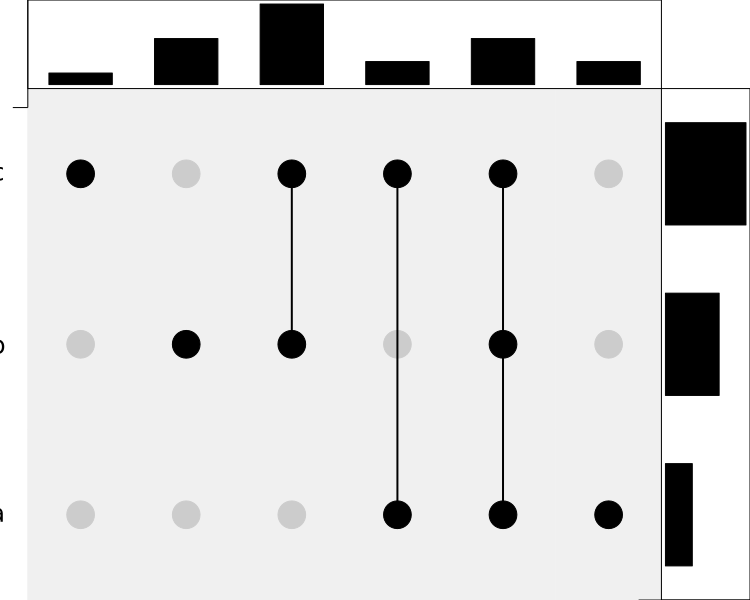

In [19]:
us = UpSet(m_univ)
us.draw()

## Using `list_to_matrix`

Convert from a dict of sets to a binary matrix, optionally with a universal set.

In [20]:
lt_simple = {
    "set1": ["a", "b", "c"],
    "set2": ["b", "c", "d", "e"]
}

bin_mat, rows, cols = list_to_matrix(lt_simple)
import pandas as pd
print(pd.DataFrame(bin_mat, index=rows, columns=cols))

bin_mat_univ, rows_u, cols_u = list_to_matrix(lt_simple, universal_set=list("abcdefghij"))
print(pd.DataFrame(bin_mat_univ, index=rows_u, columns=cols_u))


   set1  set2
a     1     0
b     1     1
c     1     1
d     0     1
e     0     1
   set1  set2
a     1     0
b     1     1
c     1     1
d     0     1
e     0     1
f     0     0
g     0     0
h     0     0
i     0     0
j     0     0


## Summary

This tutorial covered:

- Input formats: dict of sets and binary matrices
- `make_comb_mat` to create the combination matrix with modes: distinct, intersect, union
- Utility functions: `set_name`, `comb_name`, `set_size`, `comb_size`, `comb_degree`, `extract_comb`
- `UpSet()` for visualization with customizable ordering and colors
- Filtering combinations by size or degree
- UpSet annotations with `upset_top_annotation` and `upset_right_annotation`
- Universal set and complement set handling
- `list_to_matrix` for data format conversion